In [109]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import scipy.signal as signal
import soundfile as sf
from scipy.io.wavfile import write

## Etapa 1: Caracterización Estocástica y Frecuencial

Falta...
- Definir las bandas de frecuencias con más energía concentrada.
- Definir si son ergódicas y estacionarias a tramos (definir duración) o en su totalidad.

In [110]:
def prep_signal(senial, a=0.97, q=0.001):
    senial_prep = senial.copy()
    senial_prep -= np.mean(senial_prep)
    senial_prep = np.diff(senial_prep)
    senial_prep += q * (np.random.rand()*2 - 1)
    return senial_prep

def ventanear(tramo, ventana):
    N = len(tramo)
    tramo_ventaneado = tramo.copy()
    match ventana:
        case 'Gabor':
            for i in range(0, N):
                w = np.exp(-9 * i**2)
                tramo_ventaneado[i] *= w

        case 'Blackman':
            for i in range(0, N):
                w = 21/50 - 0.5 * np.cos(2*np.pi*i/(N - 1)) + 2/25 * np.cos(4*np.pi*i/(N - 1))
                tramo_ventaneado[i] *= w

        case 'Hamming':
            for i in range(0, N):
                w = 27/50 - 23/50 * np.cos(2*np.pi*i/(N-1))
                tramo_ventaneado[i] *= w

        case 'Hanning':
            for i in range(0, N):
                w = 0.5 - 0.5 * np.cos(2*np.pi*i/(N-1))
                tramo_ventaneado[i] *= w

        case 'Rectangular':
            # xd
            pass

    return tramo_ventaneado

nombre_audio = "audio3"
audio, fs = librosa.load(f"audio/{nombre_audio}.wav", sr=None)

print(audio.shape)
print(fs)

(64000,)
8000


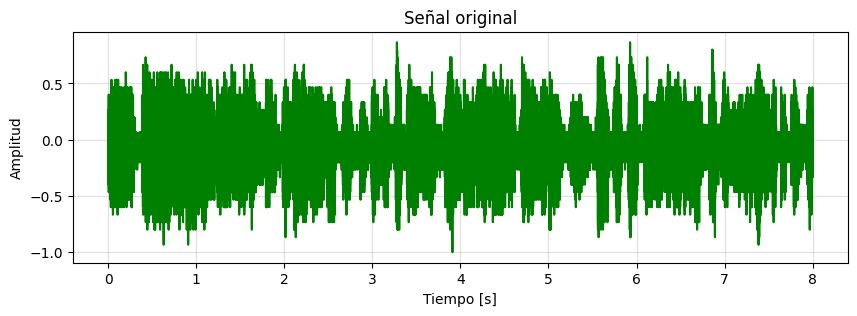

Potencia media = 0.04772217944264412


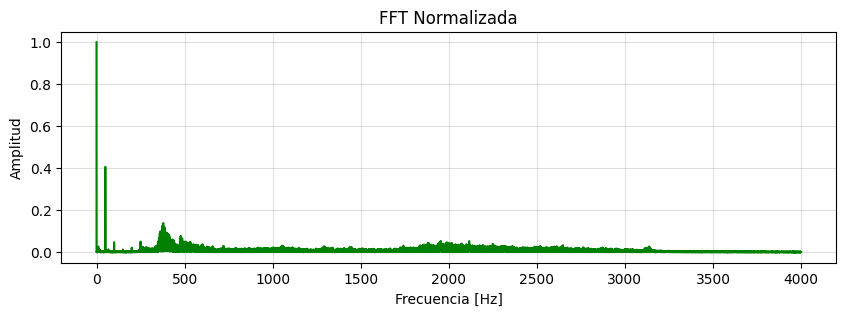

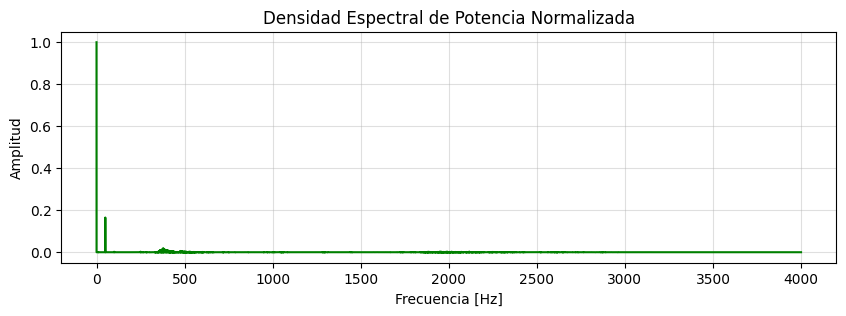

Entropía de la señal: 3.6654300421289303
Entropía de la PSD: 11.093448638916016


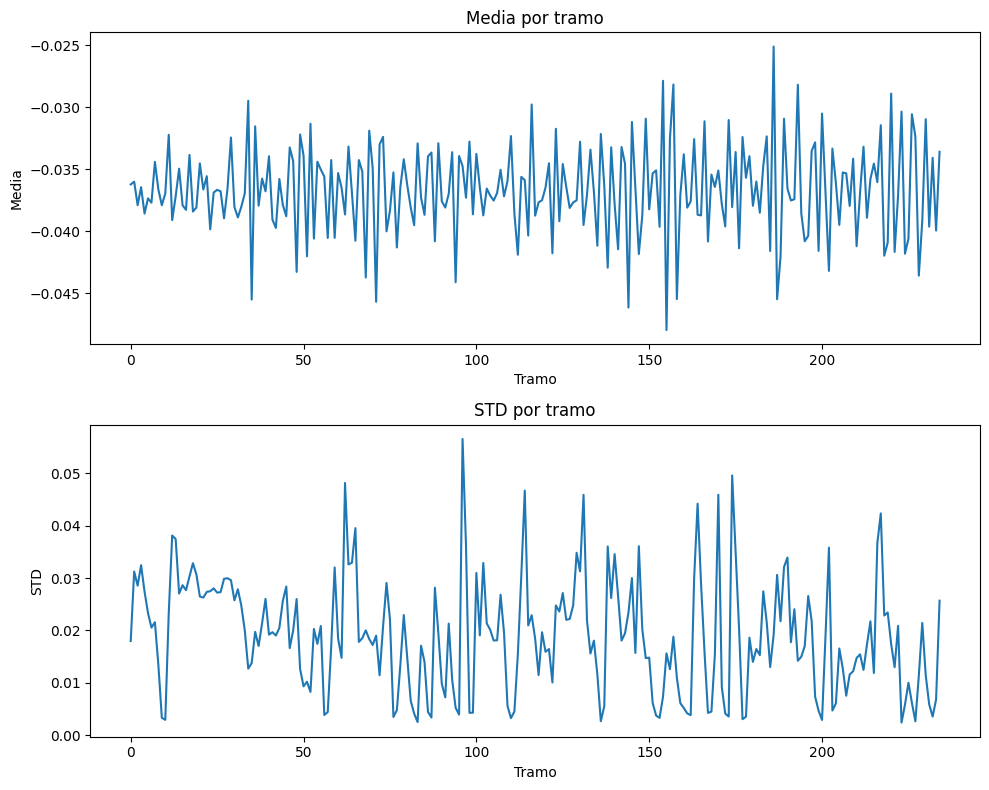

In [111]:
def graf_temp(senial, fs, figsize=(10,3), title=None):
    dom = np.arange(len(senial)) * 1/fs
    plt.figure(figsize=figsize)

    if title is None:
        plt.title("Señal original")
    else:
        plt.title(title)

    plt.ylabel("Amplitud")
    plt.xlabel("Tiempo [s]")
    plt.plot(dom, senial, c='green')
    plt.grid(True, alpha=0.4)
    plt.show()
    return dom

def graf_fft(senial, fs, figsize=(10,3), ylim=None, xticks=None):
    N = len(senial)
    
    fft = np.fft.rfft(senial, N)
    mag = np.abs(fft)
    mag /= np.max(mag)
    dom = np.fft.rfftfreq(N, 1/fs)

    plt.figure(figsize=figsize)
    plt.title("FFT Normalizada")
    plt.ylabel("Amplitud")
    if ylim is not None:
        plt.ylim(0, ylim)

    if xticks is not None:
        plt.xticks(np.arange(0, fs/2 + xticks, xticks))
    plt.xlabel("Frecuencia [Hz]")
    plt.plot(dom, mag, c='green')
    
    plt.grid(True, alpha=0.4)
    plt.show()   

def calc_fft(senial, fs):
    N = len(senial)    
    fft = np.fft.rfft(senial, N)
    mag = np.abs(fft)
    dom = np.fft.rfftfreq(N, 1/fs)  
    return dom, mag

def graf_psd(senial, fs, figsize=(10,3), ylim=None, xticks=None):
    N = len(senial)
    
    fft = np.fft.rfft(senial, N)
    mag = np.abs(fft)
    psd = mag ** 2
    psd /= np.max(psd)
    dom = np.fft.rfftfreq(N, 1/fs)

    plt.figure(figsize=figsize)
    plt.title("Densidad Espectral de Potencia Normalizada")
    plt.ylabel("Amplitud")
    if ylim is not None:
        plt.ylim(0, ylim)

    if xticks is not None:
        plt.xticks(np.arange(0, fs/2 + xticks, xticks))
    plt.xlabel("Frecuencia [Hz]")
    plt.plot(dom, psd, c='green')
    
    plt.grid(True, alpha=0.4)
    plt.show()
    return dom, psd

def calc_psd(senial, fs):
    N = len(senial)
    
    fft = np.fft.rfft(senial, N)
    mag = np.abs(fft)
    psd = mag ** 2
    dom = np.fft.rfftfreq(N, 1/fs)
    return dom, psd

def calc_potencia(senial):
    return np.mean(np.abs(senial)**2)

def calc_entropia(P):
    # Recibe histograma o PSD
    return -np.sum(P * np.log2(P))    

def obtener_tramos(senial, fs, ms, lap, start, ventana='Hamming'):
    N = len(senial)
    duracion_ventana = int(ms * fs/1000)
    desplazamiento = int(lap * fs/1000)
    arranque = int(start * fs/1000)

    tramos = [] # n_señales x algo 
    cant_tramos = (N - duracion_ventana)//desplazamiento + 1

    for j in range(cant_tramos):
        tramo = senial[arranque + desplazamiento * j : arranque + desplazamiento * j + duracion_ventana]
        if len(tramo) == duracion_ventana:
            tramo = ventanear(tramo, ventana)
            tramos.append(tramo)
    return np.array(tramos)

def graf_stats(senial, fs, ms, figsize=(10,8), minmaxMedia=None, minmaxSTD=None):
    tramos = obtener_tramos(senial, fs, ms, lap=ms, start=0)
    dom = np.arange(len(tramos))
    media = np.mean(tramos, axis=1)
    #std = np.std(tramos, axis=1)
    std = np.mean(tramos**2, axis=1)

    plt.figure(figsize=figsize)
    plt.subplot(2,1,1)
    plt.title("Media por tramo")
    plt.ylabel("Media")
    plt.xlabel("Tramo")
    if minmaxMedia:
        plt.ylim(minmaxMedia[0], minmaxMedia[1])
    
    plt.plot(dom, media)

    plt.subplot(2,1,2)
    plt.title("STD por tramo")
    plt.ylabel("STD")
    plt.xlabel("Tramo")
    if minmaxSTD:
        plt.ylim(minmaxSTD[0], minmaxSTD[1])
    
    plt.plot(dom, std)
    
    plt.tight_layout()
    plt.show()

def graf_espectrograma(senial, fs, ms=20, lap=0.5, figsize=(10,4), log_scale=True, title=None):
    nperseg = int(ms * fs / 1000)
    noverlap = int(lap * nperseg)

    f, t, Sxx = signal.spectrogram(
        senial,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=noverlap,
        scaling='density',
        mode='psd'
    )

    if log_scale:
        Sxx = 10*np.log10(Sxx + 1e-12)

    plt.figure(figsize=figsize)

    plt.pcolormesh(t, f, Sxx, shading='gouraud')

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")

    if log_scale:
        plt.colorbar(label='PSD [dB]')

    if title:
        plt.title(title)
    else:
        plt.title('Espectrograma')

    plt.tight_layout()
    plt.show()

    return f, t, Sxx


dom_t = graf_temp(audio, fs)
print(f"Potencia media = {calc_potencia(audio)}")
graf_fft(audio, fs)
graf_psd(audio, fs)

_, psd = calc_psd(audio, fs)

hist, _ = np.histogram(audio, bins=50)
prob_hist = hist/np.sum(hist)
prob_hist = prob_hist[prob_hist > 0]

prob_psd = psd/np.sum(psd)
prob_psd = prob_psd[prob_psd > 0]
H = calc_entropia(prob_hist)
print(f"Entropía de la señal: {H}")
print(f"Entropía de la PSD: {calc_entropia(prob_psd)}")

ms = 34
graf_stats(audio, fs, ms=ms)

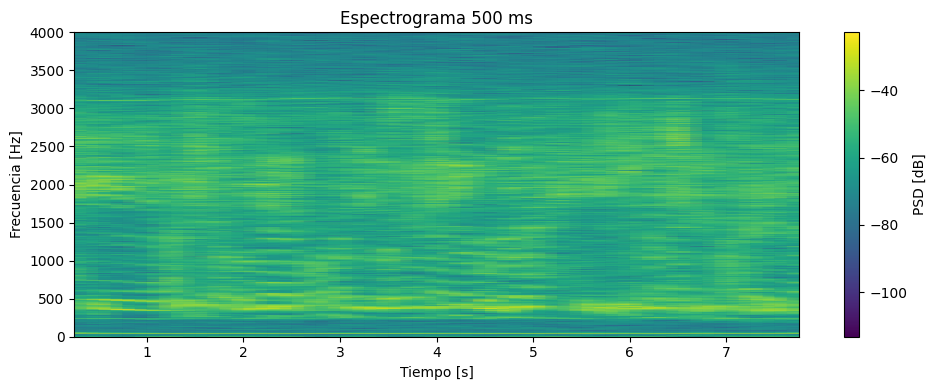

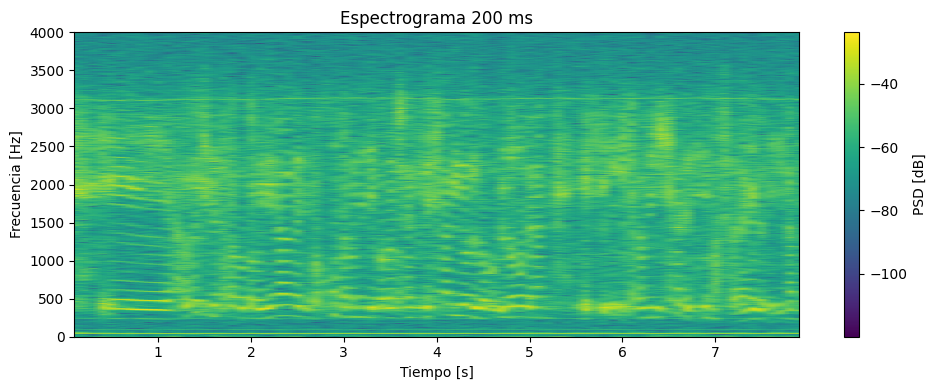

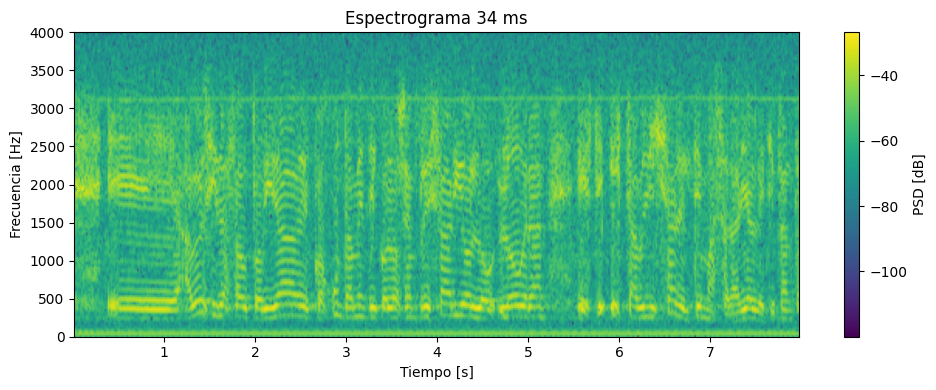

In [112]:
_ = graf_espectrograma(
    audio,
    fs,
    ms=500,
    lap=0.5,
    title='Espectrograma 500 ms'
)

_ = graf_espectrograma(
    audio,
    fs,
    ms=200,
    lap=0.5,
    title='Espectrograma 200 ms'
)

_ = graf_espectrograma(
    audio,
    fs,
    ms=34,
    lap=0.5,
    title='Espectrograma 34 ms'
)

## Etapa 2: Filtrado Digital

Falta
- Elegir y justificar el filtro seleccionado para arrastrar durante el resto del TP.

Orden: 12 1971.5835872254877


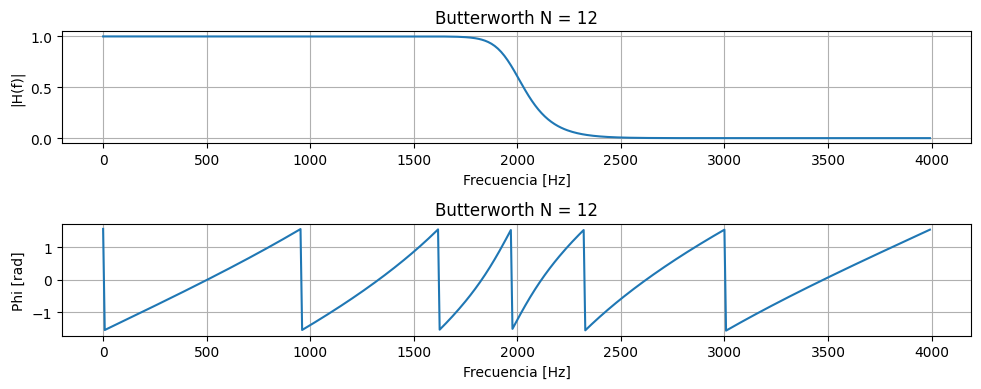

C:\Users\franc\AppData\Local\Temp\ipykernel_22660\1486118082.py:38: RuntimeWarning: divide by zero encountered in divide
  phi = np.arctan(H.real/H.imag)


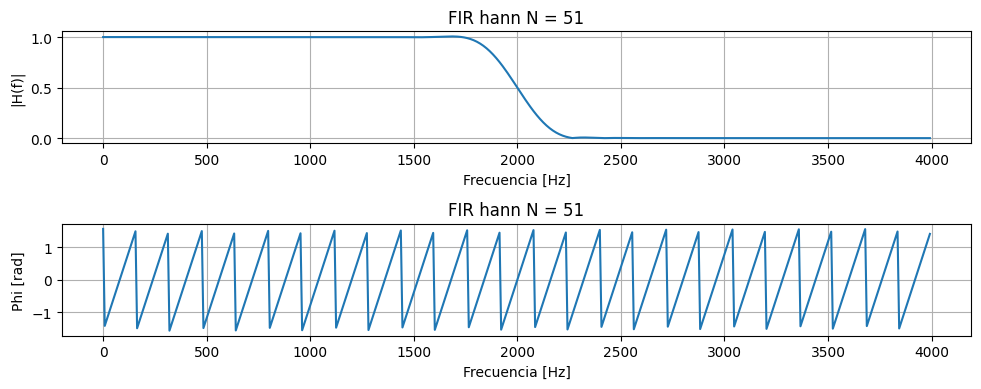

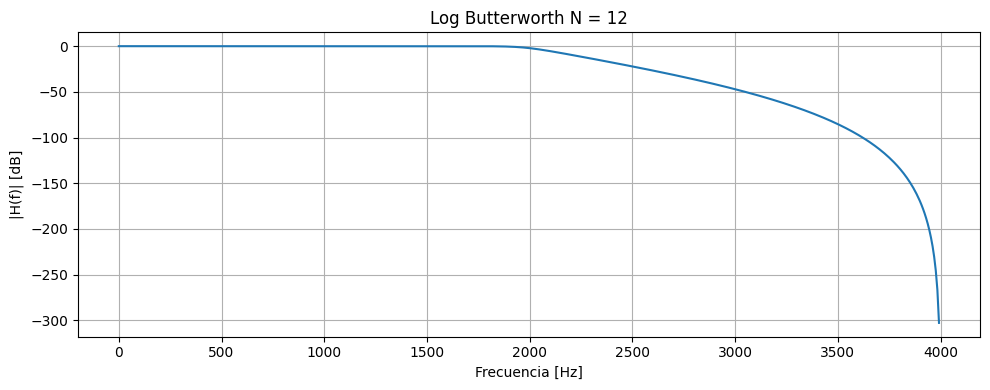

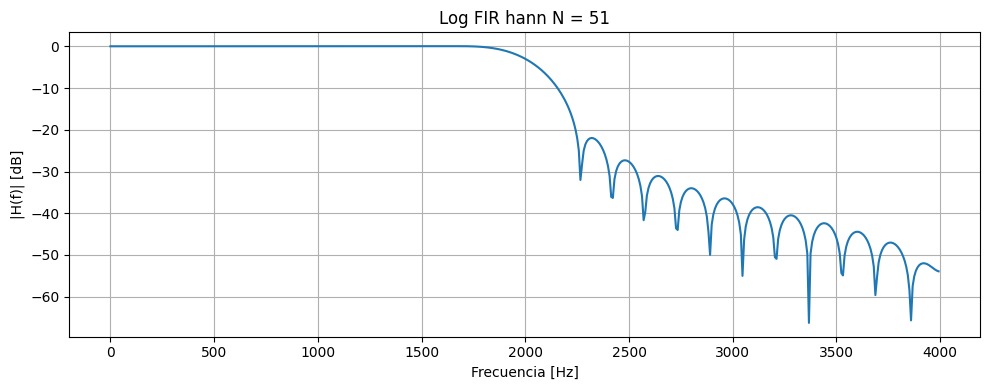

In [113]:
w_c = 2000

# IIR
eps = 100
gpass = 1
gstop = 10

# FIR
orden = 51
ventana = 'hann'


def get_iir_filter(w_c, eps, gpass, gstop):
    w_p = w_c-eps
    w_s = w_c+eps

    # Butterworth
    N_bw, wn_bw = signal.buttord(w_p, w_s, gpass, gstop, analog=False, fs=fs)
    print("Orden:", N_bw, wn_bw)

    z_bw, p_bw, k_bw = signal.butter(N_bw, wn_bw, btype = 'lowpass', analog = False, output='zpk', fs=fs)

    w, H = signal.freqz_zpk(z_bw,p_bw,k_bw,fs=fs)
    return w, H, N_bw, [z_bw, p_bw, k_bw]

def get_fir_filter(w_c, orden, ventana):
    taps = signal.firwin(orden, w_c, fs=fs, window=ventana, pass_zero=True)

    w, H = signal.freqz(taps, fs=fs)
    return w, H, taps

def graf_filter(w, H, logVisual=False, title=None, fase=False):
    h = H.copy()
    h = np.abs(h)
    if logVisual:
        h = 10*np.log10(h)

    phi = np.arctan(H.real/H.imag)

    plt.figure(figsize=(10,4))
    if fase:
        plt.subplot(2,1,1)
    plt.plot(w, h)
    plt.xlabel("Frecuencia [Hz]")
    
    if not logVisual:
        plt.ylabel("|H(f)|")
    else:
        plt.ylabel("|H(f)| [dB]")

    if title is None:
        plt.title(f"Respuesta en frecuencia")
    else:
        plt.title(title)
    plt.grid()

    if fase:
        plt.subplot(2,1,2)
        plt.plot(w, phi)
        plt.xlabel("Frecuencia [Hz]")
        plt.ylabel("Phi [rad]")
        if title is None:
            plt.title(f"Fase")
        else:
            plt.title(title)
        plt.grid()

    plt.tight_layout()
    plt.show()    
    
w_iir, H_iir, N_bw, zpk = get_iir_filter(w_c, eps, gpass, gstop)
graf_filter(w_iir, H_iir, False, title=f'Butterworth N = {N_bw}', fase=True)

w_fir, H_fir, taps = get_fir_filter(w_c, orden, ventana)
graf_filter(w_fir, H_fir, False, title=f'FIR {ventana} N = {orden}', fase=True)

graf_filter(w_iir, H_iir, True, title=f'Log Butterworth N = {N_bw}')
graf_filter(w_fir, H_fir, True, title=f'Log FIR {ventana} N = {orden}')

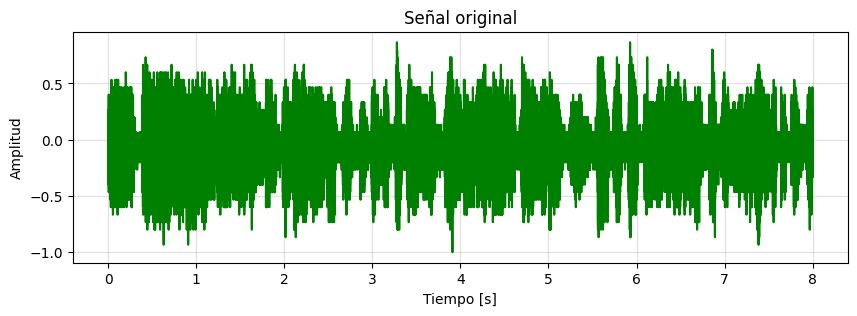

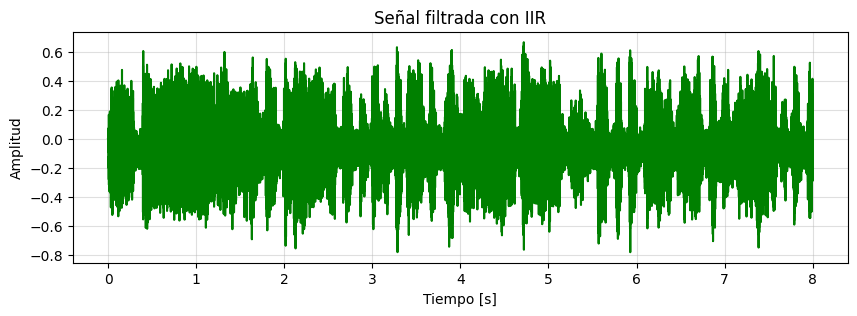

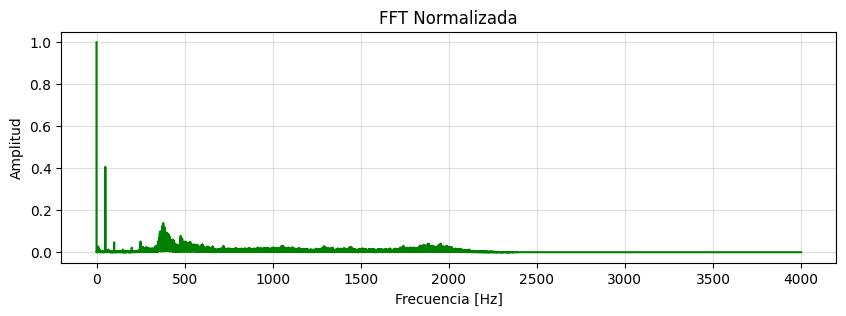

In [114]:
b, a = signal.zpk2tf(zpk[0], zpk[1], zpk[2])
audio_filtrado_iir = signal.lfilter(b, a, audio)

graf_temp(audio, fs)
graf_temp(audio_filtrado_iir, fs, title='Señal filtrada con IIR')
graf_fft(audio_filtrado_iir, fs)

sf.write(f"audio_rec/{nombre_audio}_recIIR.wav", audio_filtrado_iir, fs)

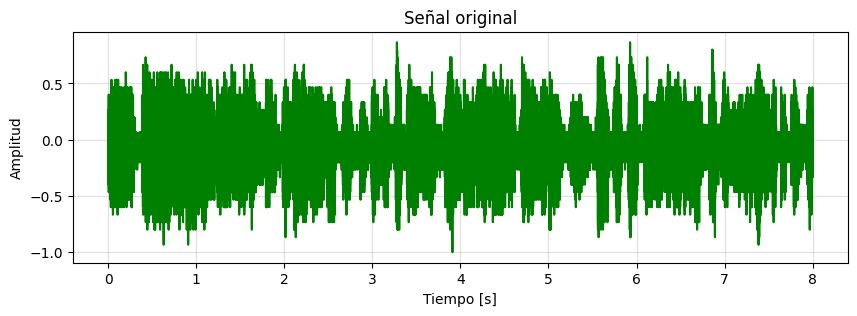

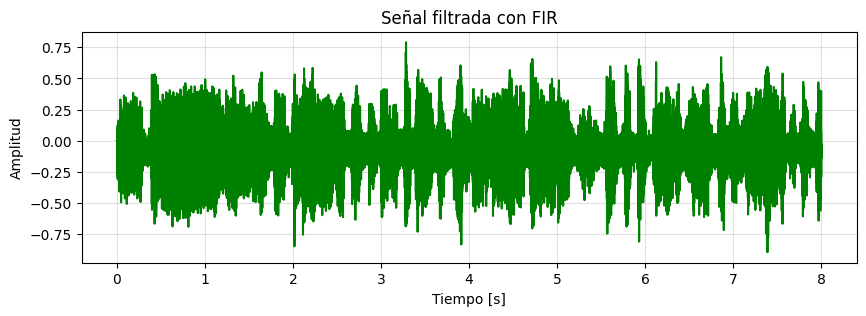

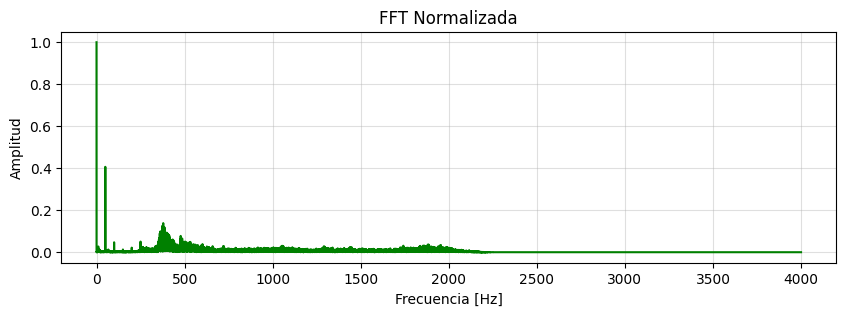

In [115]:
audio_filtrado_fir = signal.lfilter(taps, [1], audio)

graf_temp(audio, fs)
graf_temp(audio_filtrado_fir, fs, title='Señal filtrada con FIR')
graf_fft(audio_filtrado_fir, fs)

sf.write(f"audio_rec/{nombre_audio}_recFIR.wav", audio_filtrado_fir, fs)

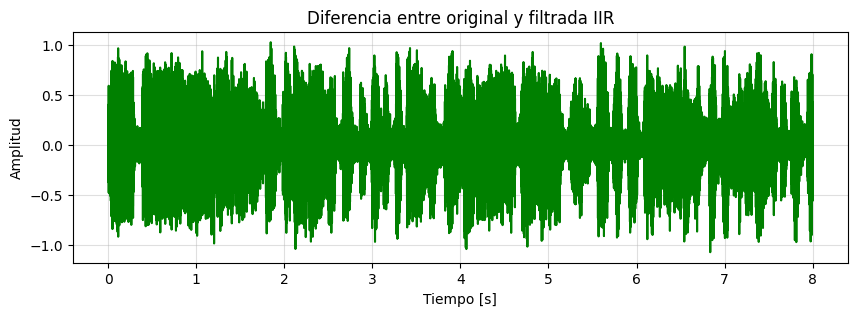

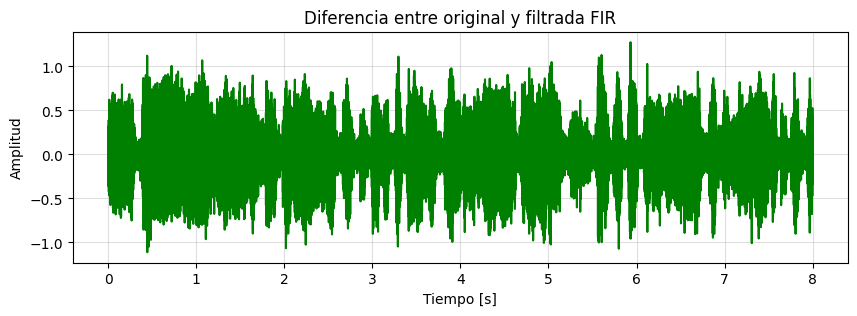

In [116]:
diff_iir = audio - audio_filtrado_iir
diff_fir = audio - audio_filtrado_fir

_ = graf_temp(diff_iir, fs, title='Diferencia entre original y filtrada IIR')
_ = graf_temp(diff_fir, fs, title='Diferencia entre original y filtrada FIR')

In [117]:
audio_filtrado = audio_filtrado_iir.copy()
audio_filtrado = prep_signal(audio_filtrado)

## Etapa 3: Modelado y Compresión mediante Predicción Lineal (LPC)

Falta
- Justificar ms de ventana.
- Elegir una ventana para mitigar el spectral leakage.
- Establecer el orden óptimo (habría que ver la progresión del error con el banco de señales y quedarse con uno suficientemente bueno, pero fijo).
- Fijar buenos umbrales para fonemas sonoros y sordos.

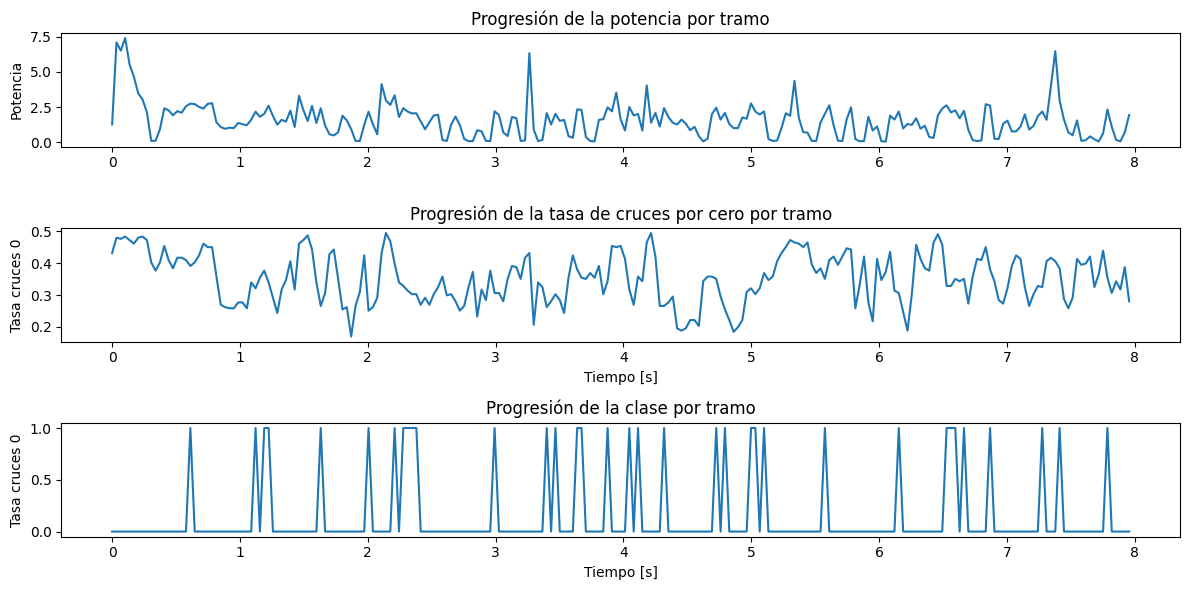

In [118]:
# Obtención Bit Sonoro/Sordo

def det_voiced(tramo, UMBRAL_SILENCIO, UMBRAL_ZCR):

    energia = np.sum(tramo**2)

    signos = np.sign(tramo)

    zcr = np.sum(
        signos[1:] != signos[:-1]
    ) / (len(tramo)-1)

    if energia < UMBRAL_SILENCIO:
        clase = 0
    elif zcr < UMBRAL_ZCR:
        clase = 1
    else:
        clase = 0

    return energia, zcr, clase

tramos = obtener_tramos(audio_filtrado, fs, ms, ms, 0)


potencias = []
zcrs = []
clases = []
UMBRAL_SILENCIO = 2
UMBRAL_ZCR = 0.4
for t in tramos:
    p, z, c = det_voiced(t, UMBRAL_SILENCIO, UMBRAL_ZCR)
    potencias.append(p)
    zcrs.append(z)
    clases.append(c)

aux_dom = np.arange(len(potencias)) * ms / 1000

plt.figure(figsize=(12,6))
plt.subplot(3,1,1)
plt.title("Progresión de la potencia por tramo")
plt.ylabel("Potencia")
plt.plot(aux_dom, potencias)

plt.subplot(3,1,2)
plt.title("Progresión de la tasa de cruces por cero por tramo")
plt.plot(aux_dom, zcrs)
plt.ylabel("Tasa cruces 0")
plt.xlabel("Tiempo [s]")

plt.subplot(3,1,3)
plt.title("Progresión de la clase por tramo")
plt.plot(aux_dom, clases)
plt.ylabel("Tasa cruces 0")
plt.xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

In [119]:
# Obtención de coeficientes LPC y ganancia G

def obtener_R(orden, senial):
    R = []
    for p in range(orden+1):
        r_s_i = 0
        for n in range(len(senial)):
            r_s_i += senial[n - p] * senial[n]
        R.append(r_s_i/len(senial))
    R = np.array(R)
    return R

def obtener_matriz_coeficientes(orden, R):
    p = orden
    A = np.zeros((p,p))
    E = [R[0]]

    for i in range(0, p):
        elemento = 0
        for j in range(0, i):
            elemento += A[j,i-1] * R[i-j]

        k_i = -1/E[-1] * (R[i+1] + elemento)
        A[i,i] = k_i
        
        for j in range(0, i):
            A[j,i] = A[j,i-1] + k_i*A[i-j-1, i-1]

        E.append(E[-1]*(1 - k_i**2))
    return A, E

def obtener_coefs_LPC(orden, tramo):
    R = obtener_R(orden, tramo)
    A, E = obtener_matriz_coeficientes(orden, R)
    a = A[:, -1]
    G = np.sqrt(E[-1])
    return a, G

In [120]:
# Obtención de pitch estimado T0

def extraer_coeficientes_cepstrales(tramo):
    v_tranf = np.fft.fft(tramo)
    v_real = np.real(v_tranf)
    v_im = np.imag(v_tranf)
    v_norm = np.sqrt(v_real**2 + v_im**2)
    v_tranf = np.log(v_norm + 1e-10)
    v_inv = np.real(np.fft.ifft(v_tranf))
    return np.array(v_inv)

def obtener_T0(tramo):
    coefs = extraer_coeficientes_cepstrales(tramo)
    coefs = np.array(coefs)

    tau_min = int(fs / 400)
    tau_max = int(fs / 80)

    coefs[:10] = 0 # Eliminamos la envolvente (quedó separada del pitch por la 
                        # extracción de coefs cepstrales)

    idx = np.argmax(coefs[tau_min:tau_max])
    tau = tau_min + idx

    valor_pico = coefs[tau]


    if valor_pico > 0.1:
        F0 = fs / tau
        T0 = 1 / F0
    else:
        F0 = 0
        T0 = 0

    return T0

In [121]:
# Emulamos la construcción del frame para cada ventana.

p = 8
frames = []

for i in range(len(tramos)):
    frame = np.zeros(p + 4)
    a, g = obtener_coefs_LPC(p, tramos[i])

    frame[:p] = a
    frame[p + 1] = g
    _, _, frame[p + 2] = det_voiced(tramos[i], UMBRAL_SILENCIO, UMBRAL_ZCR)
    frame[p + 2] = bool(frame[p + 2])
    t0 = obtener_T0(tramos[i])
    if t0 == None:
        t0 = 0
    frame[p + 3] = t0
    
    frames.append(frame)

In [122]:
# Reconstruimos la señal desde la recepción
def entrada(ms, fs, T0):
    N = int(ms/1000 * fs)
    if T0 != 0:
        T0_muestras = max(1, round(T0 * fs))
        x = np.zeros(N)
        x[::int(T0_muestras)] = 1
    else:
        x = np.random.randn(N)
    return x

def sist_autorregresivo(entrada, coefs, G):

    p = len(coefs)
    prevs = np.zeros(p)
    salida = np.zeros_like(entrada)

    for n in range(len(entrada)):
        salida[n] = -prevs @ coefs + G * entrada[n]
        prevs[1:] = prevs[:-1]
        prevs[0] = salida[n]

    return salida

def rec_signal(ms, fs, frame):
    T0 = frame[-1]
    sonoro = bool(frame[-2])
    G = frame[-3]
    A = frame[:-4]
    if sonoro:
        x = entrada(ms, fs, T0)
        salida = sist_autorregresivo(x, A, G)
    else:
        x = entrada(ms, fs, 0)
        salida = sist_autorregresivo(x, A, G)
    return salida

audio_rec = []
for f in range(len(frames)):
    audio_rec.append(rec_signal(ms, fs, frames[f]))
audio_rec = np.ravel(audio_rec)

Entropía del residuo: 4.130742480566238
Entropía de la señal: 3.6654300421289303


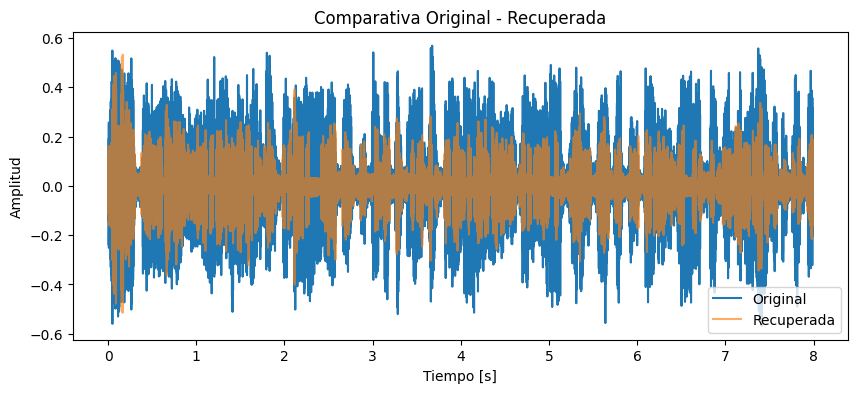

In [123]:
N = min(len(audio_filtrado), len(audio_rec))

audio_filtrado_cmp = audio_filtrado[:N]
audio_rec_cmp = audio_rec[:N]
dom_t_cmp = dom_t[:N]
diferencia = audio_filtrado_cmp - audio_rec_cmp

hist, _ = np.histogram(diferencia, bins=50)
prob_hist = hist/np.sum(hist)
prob_hist = prob_hist[prob_hist > 0]

print(f"Entropía del residuo: {calc_entropia(prob_hist)}")
print(f"Entropía de la señal: {H}")

plt.figure(figsize=(10,4))
plt.title("Comparativa Original - Recuperada")
plt.plot(dom_t_cmp, audio_filtrado_cmp, label='Original')
plt.plot(dom_t_cmp, audio_rec_cmp, label='Recuperada', alpha=0.65)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.show()


In [124]:
sf.write(f"audio_rec/{nombre_audio}_reconstruccion.wav", audio_rec_cmp, fs)

## Etapa 4: Simulación del Sistema de Comunicación

In [ ]:
def pad_zeros(x, N):
    y = np.zeros(N)
    y[:len(x)] = x
    return y

def am_sincrona(x, fs, fc):
    t = np.arange(len(x))/fs
    s_am = x * np.cos(2*np.pi*fc*t)
    return s_am

def mod_fm(x, fs, fc):
    t = np.arange(len(x))/fs
    tita_0 = 2 * np.pi * fc * t
    tita_1 = 2 * np.pi * np.cumsum(x)/fs

    s_fm = np.cos(tita_0 + tita_1)
    return s_fm

def dam_sincrona(x, fs, fc):
    t = np.arange(len(x))/fs
    s_dem = 2 * x * np.cos(2*np.pi*fc*t)
    
    wn = (fc * 0.8) / (fs / 2)
    b, a = signal.butter(5, wn, btype='low')
    s_dem = signal.filtfilt(b, a, s_dem)
    
    return s_dem

def pasa_banda(x, fs, f_inf, f_sup, orden=5):
    wn = [f_inf/(fs/2), f_sup/(fs/2)]
    b, a = signal.butter(orden, wn, btype='bandpass')
    return signal.filtfilt(b, a, x)

In [166]:
FSs = []
audios = []
formatos = ["mp3", "mp3", "wav"]
for i in range(1,4):
    audio, fs = librosa.load(f"audio/audio{i}.{formatos[i-1]}", sr=None)
    FSs.append(fs)
    audios.append(audio)
    print(len(audio), fs)

92160 44100
588672 48000
64000 8000


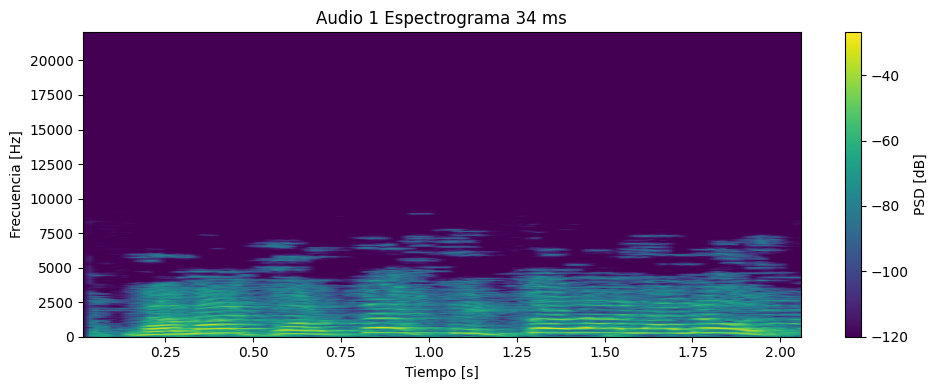

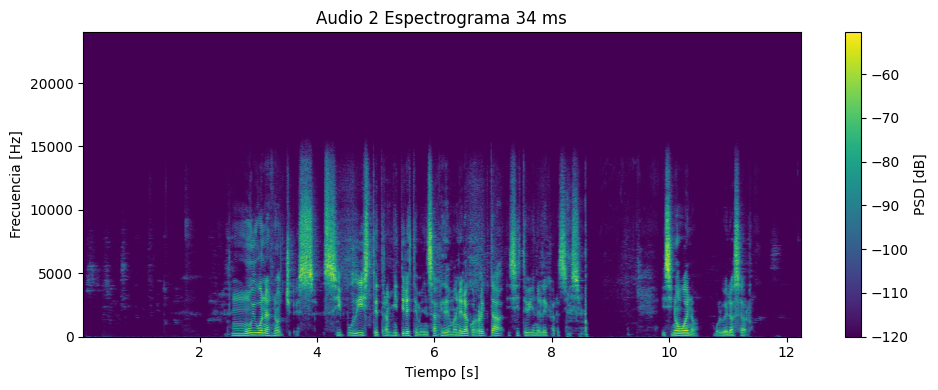

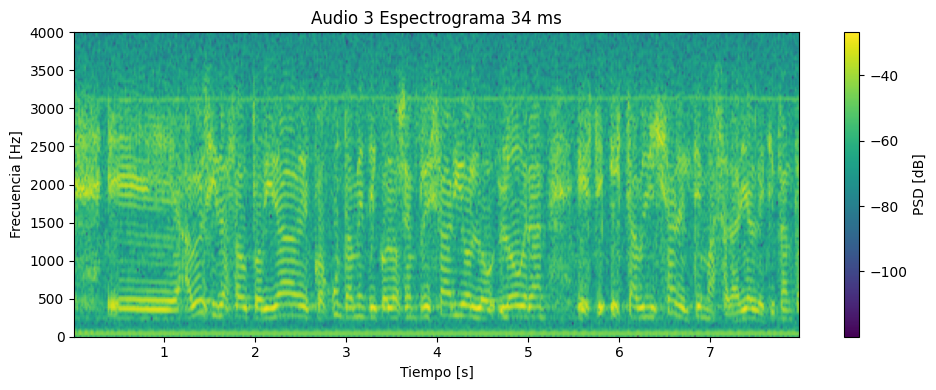

In [177]:
_ = graf_espectrograma(
    audios[0],
    FSs[0],
    ms=ms,
    lap=0.5,
    title=f'Audio 1 Espectrograma {ms} ms'
)

_ = graf_espectrograma(
    audios[1],
    FSs[1],
    ms=ms,
    lap=0.5,
    title=f'Audio 2 Espectrograma {ms} ms'
)

_ = graf_espectrograma(
    audios[2],
    FSs[2],
    ms=ms,
    lap=0.5,
    title=f'Audio 3 Espectrograma {ms} ms'
)

Vemos que...

* Audio 1: Abarca hasta 7500 Hz
* Audio 2: Abarca hasta 15000 Hz
* Audio 3: Abarca hasta 3500 Hz

In [183]:
FCs = [50000, 70000, 90000]
B_AM = np.max(FCs) - np.min(FCs) + 2 * 5000 # se suma el ancho del filtrado en recepción
print(f"Ancho de banda requerido: {B_AM}")

frecDEM = 200000

def transmision_AM(seniales, FCs, FSs, frecDEM):
    n = len(FSs)

    duraciones = [
        len(audio)/fs
        for audio, fs in zip(seniales, FSs)
    ]

    dur_max = max(duraciones)

    N = int(dur_max * frecDEM)

    AM_sum = np.zeros(N)
    for i in range(n):
        fs = FSs[i]
        fc = FCs[i]
        audio = seniales[i]
        N_audio_new = int(len(audio) * frecDEM / fs)
        audio_up = signal.resample(audio, N_audio_new)
        audio_up = pad_zeros(audio_up, N)
        audio_AM = am_sincrona(audio_up, frecDEM, fc)
        AM_sum += audio_AM

    return AM_sum

def recepcion_AM(AM_sum, FCs, FSs, frecDEM, ancho, orden=5):
    n = len(FSs)

    RECS = []
    for i in range(n):
        fs = FSs[i]
        fc = FCs[i]
        rec_audio_AM = pasa_banda(AM_sum, frecDEM, fc - ancho, fc + ancho, orden)
        rec_audio = dam_sincrona(rec_audio_AM, frecDEM, fc)
        # Normalizar a [-1, 1]
        rec_audio = rec_audio / np.max(np.abs(rec_audio))
        rec_audio = signal.resample(
            rec_audio,
            int(len(rec_audio) * fs / frecDEM)
        )

        RECS.append(rec_audio)

    return RECS

Ancho de banda requerido: 50000


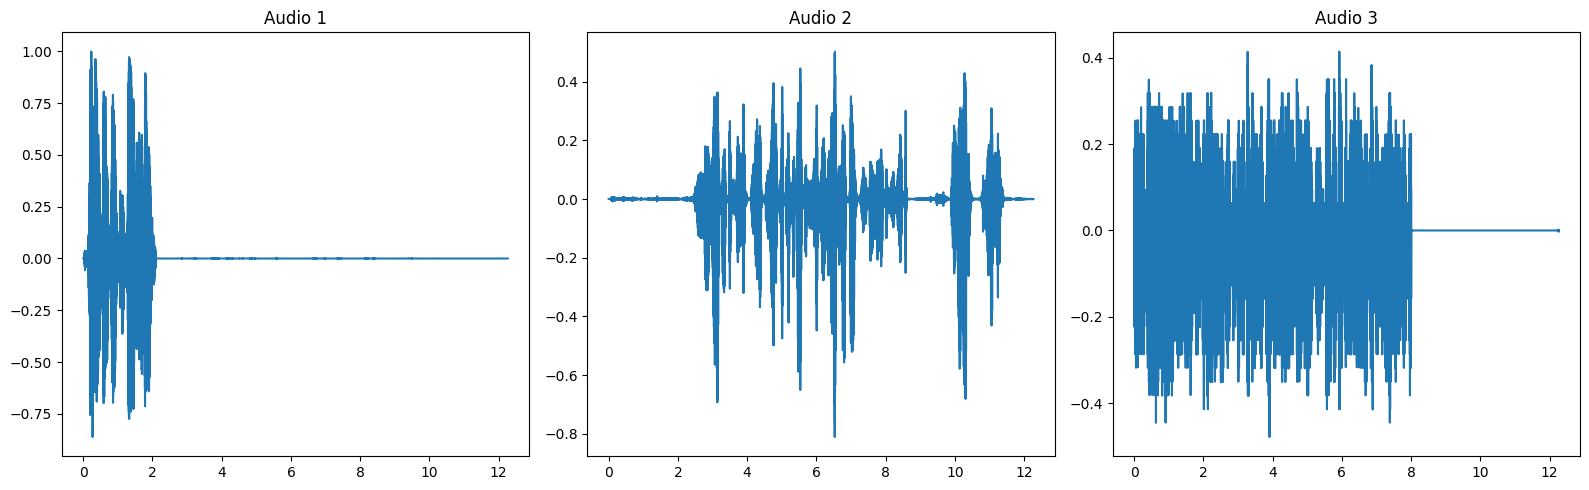

In [184]:
ancho = 5000
AM_sum = transmision_AM(audios, FCs, FSs, frecDEM)
RECS = recepcion_AM(AM_sum, FCs, FSs, frecDEM, ancho)

plt.figure(figsize=(16,5))

for i in range(len(RECS)):
    dom = np.arange(len(RECS[i])) * 1/FSs[i]

    plt.subplot(1,3,i+1)
    plt.title(f"Audio {i+1}")
    plt.plot(dom, RECS[i])
plt.tight_layout()
plt.show()

In [185]:
delta_f = 5000

# Por regla de Carlson
B_1 = 2 * (delta_f + 7500)
B_2 = 2 * (delta_f + 15000)
B_3 = 2 * (delta_f + 3500)
print(B_1, B_2, B_3)

FCs = [50000, 100000, 150000]

frecDEM = 350000

max_B = np.max([B_1, B_2, B_3])
B_FM = np.max(FCs) - np.min(FCs) + np.max([B_1, B_2, B_3])
print(f"Ancho de banda requerido por FM: {B_FM}")

def transmision_FM(seniales, FCs, FSs, frecDEM):
    n = len(FSs)

    duraciones = [
        len(audio)/fs
        for audio, fs in zip(seniales, FSs)
    ]

    dur_max = max(duraciones)

    N = int(dur_max * frecDEM)

    FM_sum = np.zeros(N)
    for i in range(n):
        fs = FSs[i]
        fc = FCs[i]
        audio = seniales[i]
        N_audio_new = int(len(audio) * frecDEM / fs)
        audio_up = signal.resample(audio, N_audio_new)
        audio_up = pad_zeros(audio_up, N)
        audio_FM = mod_fm(audio_up, frecDEM, fc)
        FM_sum += audio_FM

    return FM_sum

25000 40000 17000
Ancho de banda requerido por FM: 140000


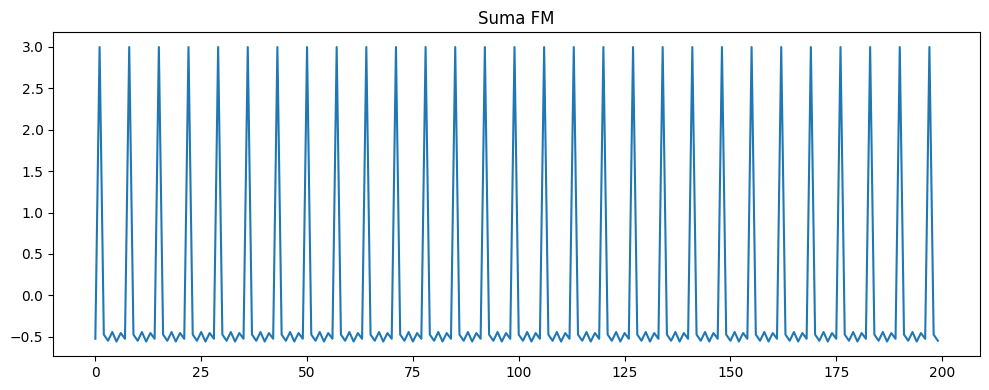

In [ ]:
FM_sum = transmision_FM(audios, FCs, FSs, frecDEM)

plt.figure(figsize=(10,4))
plt.title(f"Suma FM")
plt.plot(FM_sum[50000:50200])
plt.tight_layout()
plt.show()

In [190]:
P_AM = np.mean(AM_sum**2)
P_FM = np.mean(FM_sum**2)

print(f"Potencia transmitida")
print(f"AM: {P_AM}")
print(f"FM: {P_FM}")

Potencia transmitida
AM: 0.017322661763856707
FM: 1.5000010454672066
